# PROJECT ML - Real Estate Price Prediction

This project aims to build machine learning models for predicting real estate prices based on transaction data.

The dataset includes multiple types of properties, which are later segmented to build specialized models for each category.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

import json
import os

## Data Integration

Multiple quarterly datasets are combined into a single DataFrame to create a unified dataset for analysis and modeling.

Each file represents real estate transactions for a specific time period.

In [2]:
data_path = Path("data")

file_paths = sorted(data_path.glob("*.xlsx"))

print("Found files:", len(file_paths))

dfs = []
for file in file_paths:
    df = pd.read_excel(file)
    dfs.append(df)

real_estate_df = pd.concat(dfs, ignore_index=True)

print("\nCombined shape:", real_estate_df.shape)
real_estate_df.head()

Found files: 11

Combined shape: (578950, 18)


,type_of_property,form_sobs,reg_data,prav_doc,summa,type_dogovora,notarius,vid_prava,oblast,gorod,rayon,ulica,ar_code,plosh_ob,kato,cena_1_kv,kategoria_cen,sdu_load_in_dt
0,Частный дом,Индивидуальная,2022-02-01 15:46:00,Договор дарения № 22-2000-10041 (№ 191 от 31 я...,0.0,NaN,NaN,Право собственности,г. Алматы,р-н Жетысуский,ул. Хожамьярова,"г. Алматы, р-н Жетысуский, ул. Хожамьярова, д....",CA1EB7D64A87372E7CCB2D2EF0CF89E715DD61E25A2FA9...,0.0,751510000,0.000000e+00,1000k+,2024-09-16 17:38:55
1,Частный дом,Общая совместная,2022-03-14 17:20:10,Договор купли-продажи № 22-2000-37803 (№ 239 о...,25000000.0,Договор купли-продажи,D4F3C3C969024E0CA5D150E07807C73C29D2B21E45B481...,Право собственности,г. Алматы,р-н Турксибский,ул. Кустанайская,"г. Алматы, р-н Турксибский, ул. Кустанайская, ...",24BB4145C765A5DA3F9BD70DB4D7632E910ED069A94C72...,0.0,751910000,0.000000e+00,1000k+,2024-09-16 17:38:55
2,Частный дом,Индивидуальная,2022-02-03 09:24:05,Договор купли-продажи № 22-2000-11947 (№ 797 о...,40000000.0,Договор купли-продажи,EE2AB9F3652475FC61820A1A56F2AF14FC80AED8A179F4...,Право собственности,г. Алматы,р-н Жетысуский,ул. Никольской,"г. Алматы, р-н Жетысуский, ул. Никольской, д. 75",273CAD5CA0A7BB9AA6EFD5DE371D6FA0BE1E672DE6AAA4...,14.2,751510000,2.816901e+06,1000k+,2024-09-16 17:38:55
3,Частный дом,Общая долевая,2022-03-17 15:02:20,Свидетельство о праве на наследство по закону ...,0.0,NaN,NaN,Право собственности,г. Алматы,р-н Алатауский,мкр. Карасу,"г. Алматы, р-н Алатауский, мкр. Карасу, пер. А...",DE2D2862C9CF85FD31902A6AE708ABED919AC3DC6E1D58...,0.0,751210000,0.000000e+00,1000k+,2024-09-16 17:38:55
4,Частный дом,Индивидуальная,2022-03-31 15:58:22,Акт приемки построенного объекта в эксплуата...,0.0,NaN,NaN,Изменение характеристик и данных правообладателя,г. Алматы,р-н Алатауский,мкр. Айгерим-2,"г. Алматы, р-н Алатауский, мкр. Айгерим-2, ул....",D9F99F719587B79EF0C3CABC43B9441F905A5E9CCF5A09...,0.0,751210000,0.000000e+00,1000k+,2024-09-16 17:38:55


## Exploratory Data Analysis

Initial inspection of the dataset is performed to understand:

- Missing values across features
- Cardinality of categorical variables
- Potential data quality issues (high cardinality, irrelevant fields)

This step helps identify features that require cleaning, transformation, or removal.

In [3]:
missing = real_estate_df.isna().sum().sort_values(ascending=False)
missing_percent = (real_estate_df.isna().mean() * 100).sort_values(ascending=False)

missing_info = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print("Missing values:")
display(missing_info)

print("\n" + "="*80)

unique_counts = real_estate_df.nunique().sort_values(ascending=False)
print("Unique values per column:")
display(unique_counts)

Missing values:


,missing_count,missing_percent
notarius,440605,76.104154
type_dogovora,440605,76.104154
kategoria_cen,79875,13.796528
rayon,548,0.094654
type_of_property,322,0.055618
gorod,92,0.015891
prav_doc,38,0.006564
form_sobs,0,0.000000
summa,0,0.000000
reg_data,0,0.000000



Unique values per column:


prav_doc            354838
reg_data            348792
ulica               298112
ar_code             296120
cena_1_kv           126738
summa                53894
plosh_ob              9866
notarius              1810
rayon                 1760
type_dogovora           67
gorod                   53
type_of_property        29
kategoria_cen           21
oblast                  18
vid_prava               17
kato                    14
form_sobs                3
sdu_load_in_dt           1
dtype: int64

### Key Observations

- Some features contain a high percentage of missing values (e.g., notarius, type_dogovora)
- Certain columns have extremely high cardinality (e.g., prav_doc, ulica)
- These characteristics indicate that feature selection and cleaning are necessary before modeling

---

## Global Data Preprocessing

This section performs initial data cleaning steps applied to the entire dataset before segmentation.

The goal is to:
- Remove irrelevant and noisy features
- Prevent target leakage
- Standardize the dataset for downstream modeling


### Feature Selection and Leakage Prevention

At this stage, irrelevant and potentially harmful features are removed.

* Dropped features with low analytical value and with excessive missing values (`notarius`, `type_dogovora`)
* Removed location-specific and auxiliary fields that do not contribute to model performance (`ulica`, `ar_code`, `sdu_load_in_dt`, `oblast`)
* Excluded `kategoriya_cen` to prevent **target leakage**, as it directly encodes price-related information

In [4]:
df = real_estate_df.copy()

print("Initial shape:", df.shape)

df = df.drop(columns=[
    'kategoria_cen',
    'notarius',
    'type_dogovora',
    'ulica',
    'ar_code',
    'sdu_load_in_dt',
    'oblast',
    'vid_prava'
])

print("After dropping columns:", df.shape)

Initial shape: (578950, 18)
After dropping columns: (578950, 10)


### Temporal Feature Engineering

The original transaction date is decomposed into meaningful components:

- Year — used for train/validation/test split
- Quarter — captures seasonal patterns in the real estate market

The original datetime column is removed after transformation.

In [5]:
df["year"] = df["reg_data"].dt.year
df["quarter"] = df["reg_data"].dt.quarter

df = df.drop(columns=["reg_data"])

print("After date transformation:", df.shape)

After date transformation: (578950, 11)


### Initial Data Filtering

Basic filtering is applied to remove invalid observations:

- Transactions with zero price (`summa = 0`)
- Properties with zero area (`plosh_ob = 0`)

These records are considered invalid and would negatively affect model training.

In [6]:
df = df[df["summa"] > 0]

print("After filtering summa > 0:", df.shape)

df = df[df["plosh_ob"] > 0]

print("After removing zero area:", df.shape)

After filtering summa > 0: (323265, 11)
After removing zero area: (279681, 11)


### Handling Missing Core Features

Rows with missing values in critical features are removed to ensure data consistency.

The following fields are essential for modeling:
- Location (gorod, rayon)
- Property type (type_of_property)
- Transaction information (prav_doc)

Removing these rows ensures that the model is trained on complete and reliable data.

In [7]:
df = df.dropna(subset=['gorod', 'rayon', 'type_of_property', 'prav_doc'])

print("After removing missing values:", df.shape)

After removing missing values: (279485, 11)


### Market Transaction Filtering

The dataset is filtered to include only market-based transactions.

Only records corresponding to sale transactions ("купли-продажи") are retained.

This step removes:
- Gifts
- Inheritance transfers
- Other non-market transactions

These types of records do not reflect real market prices and would introduce noise into the model.

In [8]:
df['prav_doc'].str.contains('купли-продажи', case=False, na=False).mean()

np.float64(0.839250764799542)

In [9]:
df = df[df['prav_doc'].str.contains('купли-продажи', case=False, na=False)]

df = df.drop(columns=['prav_doc'])

print("After keeping only market transactions:", df.shape)

After keeping only market transactions: (234558, 10)


### Column Renaming and Data Consistency

Column names are adjusted to ensure consistency and correct interpretation:

- `gorod` is mapped to `rayon`
- `rayon` is mapped to `street`

This step resolves inconsistencies in the original dataset structure.

In [10]:
df = df.rename(columns={
    'gorod': 'rayon',
    'rayon': 'street'
})

df.head()

,type_of_property,form_sobs,summa,rayon,street,plosh_ob,kato,cena_1_kv,year,quarter
2,Частный дом,Индивидуальная,40000000.0,р-н Жетысуский,ул. Никольской,14.2,751510000,2.816901e+06,2022,1
5,Частный дом,Индивидуальная,6000000.0,р-н Турксибский,мкр. Жас канат,50.2,751910000,1.195219e+05,2022,1
8,Встроенноe помещение,Общая совместная,26048000.0,р-н Алатауский,мкр. Дарабоз,70.4,751210000,3.700000e+05,2022,1
9,Встроенноe помещение,Индивидуальная,21000000.0,р-н Бостандыкский,ул. Наурызбай Батыра,23.8,751410000,8.823529e+05,2022,1
11,Встроенноe помещение,Индивидуальная,177000000.0,р-н Медеуский,пр. Достык,1090.9,751710000,1.622514e+05,2022,1


### Location Field Consistency Filtering

During exploratory analysis, several incorrect or inconsistent values were identified in the `rayon` feature.

Examples included street names, residential complexes, and duplicated district names with alternative formatting.

Since these values represented a very small fraction of the dataset and did not correspond to valid administrative districts, they were excluded to improve data consistency and frontend input validation.

This filtering step primarily affects user-facing components and has a negligible impact on overall model performance.

In [11]:
df = df[df["rayon"].isin([
    " р-н Алатауский",
    " р-н Алмалинский",
    " р-н Ауэзовский",
    " р-н Бостандыкский",
    " р-н Жетысуский",
    " р-н Медеуский",
    " р-н Наурызбайский",
    " р-н Турксибский"
])]

### Result of Preprocessing

The dataset has been:

- Cleaned from invalid and non-market transactions
- Standardized across all features
- Reduced to relevant and reliable variables

It is now ready for segmentation into homogeneous groups and subsequent model training.

---

## Post-Cleaning Data Inspection

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_info = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print("Missing values:")
display(missing_info)

print("\n" + "="*80)

unique_counts = df.nunique().sort_values(ascending=False)
print("Unique values per column:")
display(unique_counts)

Missing values:


,missing_count,missing_percent
type_of_property,0,0.0
form_sobs,0,0.0
summa,0,0.0
rayon,0,0.0
street,0,0.0
plosh_ob,0,0.0
kato,0,0.0
cena_1_kv,0,0.0
year,0,0.0
quarter,0,0.0



Unique values per column:


cena_1_kv           102581
summa                38264
plosh_ob              6024
street                1323
type_of_property        23
kato                     9
rayon                    8
quarter                  4
form_sobs                3
year                     3
dtype: int64

After preprocessing, the dataset is re-evaluated to ensure that:

- Missing values have been handled
- Feature distributions are consistent
- No critical information was lost during cleaning

---

## Data Segmentation

After preprocessing, the dataset is divided into homogeneous segments based on property type.

This step is critical because different types of real estate follow fundamentally different pricing dynamics. Training a single model on heterogeneous data would lead to poor generalization and unstable predictions.

The dataset is segmented into the following groups:

1. Apartments (Квартира)
2. Houses (Частный дом)
3. Land plots (Земельный участок)
4. Commercial properties (Помещение)

Each segment is modeled independently to better capture domain-specific patterns and improve prediction accuracy.

In [13]:
df['type_of_property'].value_counts()

type_of_property
Квартира                            163580
Помещение                            19918
Парковочное место                    18391
Частный дом                          11196
Земельный участок                     6922
Гараж                                 4442
Кладовка                              3285
Строение                              2507
Строение                              1699
Встроенноe помещение                  1106
Основное строение                      602
Сооружение                             432
Дача                                   181
Здание                                 139
Многоквартирный дом                     36
Прочее                                  34
Магазин                                 26
Прочее ВО                               12
Имущественный комплекс                   7
Встроенно-пристроенное помещение         6
Прочее ПО                                3
Аптека                                   2
Комната в общежитии                  

### Segment Distribution

The dataset is highly imbalanced across property types, with apartments dominating the data.

Rare property types are excluded into broader categories to ensure sufficient data for reliable model training.

In [14]:
def split_segments(df):
    return {
        "apartment": df[df['type_of_property'] == 'Квартира'].copy(),
        "house": df[df['type_of_property'].isin(['Частный дом'])].copy(),
        "land": df[df['type_of_property'] == 'Земельный участок'].copy(),
        "commercial": df[df['type_of_property'] == "Помещение"].copy()
    }

In [15]:
segments = split_segments(df)

df_apartments = segments["apartment"]
df_houses = segments["house"]
df_land = segments["land"]
df_commercial = segments["commercial"]

print("Apartments:", df_apartments.shape)
print("Houses:", df_houses.shape)
print("Land:", df_land.shape)
print("Commercial:", df_commercial.shape)

Apartments: (163580, 10)
Houses: (11196, 10)
Land: (6922, 10)
Commercial: (19918, 10)


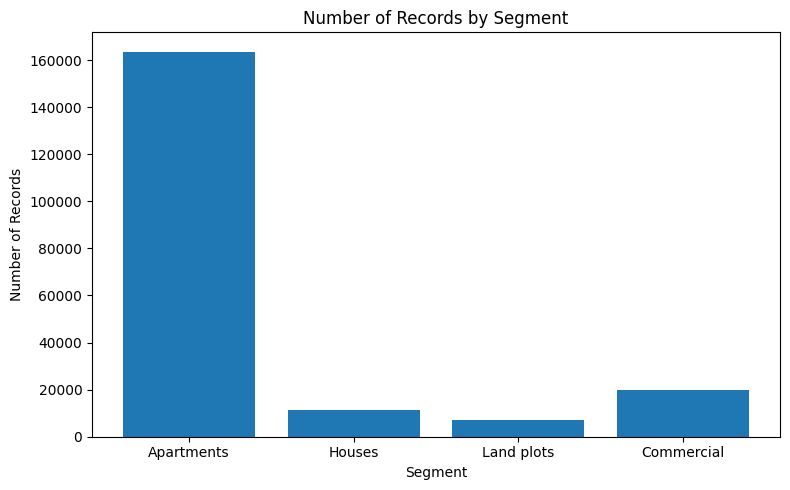

In [16]:
segment_counts = {
    "Apartments": len(df_apartments),
    "Houses": len(df_houses),
    "Land plots": len(df_land),
    "Commercial": len(df_commercial)
}

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.keys(), segment_counts.values())
plt.title("Number of Records by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Segment-Specific Preprocessing: **Apartments**

In this section, additional preprocessing steps are applied specifically to apartment data.

Apartments represent the most homogeneous and well-structured segment, making them suitable for establishing a baseline modeling approach.

The following steps are performed:
- Removal of unrealistic area values
- Filtering of price-related outliers
- Preparation of features for modeling

### Area-Based Filtering

To ensure realistic property sizes, domain-based constraints are applied:

- Very small values (< 15 m²) are removed, as they likely represent data errors or non-residential units
- Extremely large apartments (> 200 m²) are excluded to remove rare outliers

This step focuses the analysis on typical residential properties and improves model stability.

In [18]:
df_apartments["plosh_ob"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    163580.000000
mean         57.835911
std          38.822514
min           1.000000
1%            1.000000
5%           20.000000
50%          51.600000
95%         113.500000
99%         180.800000
max        2399.000000
Name: plosh_ob, dtype: float64

In [19]:
df_apartments = df_apartments[
    (df_apartments["plosh_ob"] >= 15) & 
    (df_apartments["plosh_ob"] <= 200)
]

print("After area filtering:", df_apartments.shape)

After area filtering: (157048, 10)


The majority of apartment transactions fall within this range, confirming that the applied constraints preserve the core data distribution.

### Distribution After Area Filtering

The distribution of apartment sizes after filtering shows a dense and consistent range without extreme outliers.

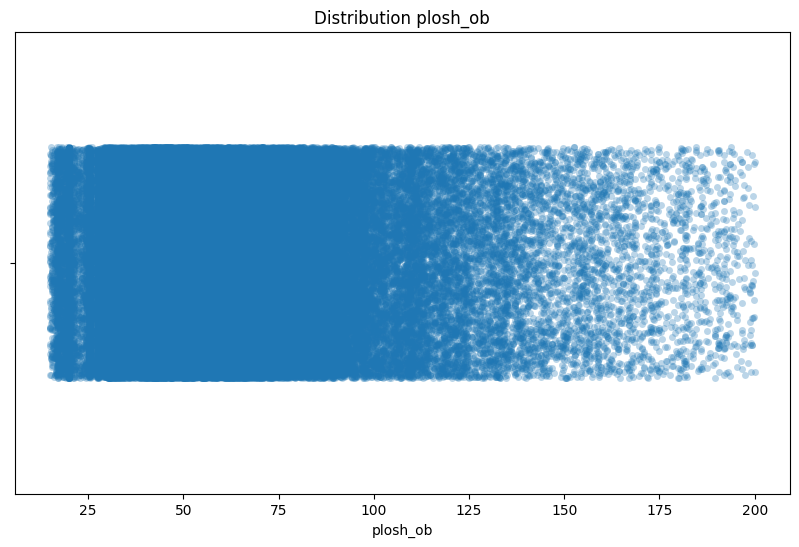

In [20]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df_apartments['plosh_ob'], alpha=0.3, jitter=0.25)

plt.title('Distribution plosh_ob')
plt.show()

### Price-Based Filtering

To ensure realistic and market-consistent pricing, constraints are applied to both total price and price per square meter.

The thresholds are derived from percentile analysis and domain knowledge:

- Total price is restricted to the range 5M – 120M
- Price per square meter is limited to 100k – 1.5M

These constraints remove extreme outliers while preserving the majority of valid market transactions.

This step significantly reduces noise and improves the learnability of the target variable.

In [21]:
df_apartments[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,1.570480e+05,157048.000000,1.570480e+05
mean,2.929041e+26,57.924322,8.603678e+24
std,8.207771e+28,26.577827,2.411137e+27
min,1.000000e+00,15.000000,5.042864e-03
1%,3.330776e+06,19.500000,6.810457e+04
5%,9.599132e+06,25.500000,2.166065e+05
50%,2.560000e+07,52.300000,5.198662e+05
95%,7.100000e+07,110.500000,9.500000e+05
99%,1.236864e+08,156.300000,1.425000e+06
max,2.300000e+31,200.000000,6.845238e+29


In [22]:
print("Before filtering:", df_apartments.shape)

df_apartments = df_apartments[
    (df_apartments["summa"] >= 5_000_000) &
    (df_apartments["summa"] <= 120_000_000) &
    (df_apartments["cena_1_kv"] >= 100_000) &
    (df_apartments["cena_1_kv"] <= 1_500_000)
]

print("After filtering:", df_apartments.shape)

Before filtering: (157048, 10)
After filtering: (150882, 10)


In [23]:
df_apartments[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,1.508820e+05,150882.000000,1.508820e+05
mean,3.031709e+07,57.266576,5.402348e+05
std,1.755802e+07,24.879216,2.044976e+05
min,5.000000e+06,15.000000,1.000000e+05
1%,7.000000e+06,19.700000,1.349460e+05
5%,1.075000e+07,27.500000,2.405024e+05
50%,2.580000e+07,52.200000,5.212316e+05
95%,6.620000e+07,106.200000,9.069776e+05
99%,9.968975e+07,144.300000,1.183812e+06
max,1.200000e+08,200.000000,1.500000e+06


### Post-Filtering Summary

After applying the filters:

- The distribution of prices becomes more stable
- Extreme outliers are removed
- The dataset better reflects typical market conditions

This prepares the data for reliable model training.

---

## Model Comparison Within Segment

At this stage, multiple models and feature configurations are evaluated within the apartment segment.

The objective is to:

- Identify the most effective modeling approach
- Select the best feature representation
- Establish a baseline pipeline for other segments

Models are evaluated using consistent metrics:
- RMSE (log scale)
- MAE (log scale)
- R²
- MAE (original price scale)

This ensures a fair and interpretable comparison.


In [24]:
df_apartments = df_apartments.copy()
df_apartments['target'] = np.log(df_apartments['summa'])

In [25]:
def evaluate_model(model_name, y_train, y_train_pred, y_test, y_test_pred):
    train_rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae_log = mean_absolute_error(y_train, y_train_pred)
    test_mae_log = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    y_train_real = np.exp(y_train)
    y_test_real = np.exp(y_test)
    y_train_pred_real = np.exp(y_train_pred)
    y_test_pred_real = np.exp(y_test_pred)

    train_mae_real = mean_absolute_error(y_train_real, y_train_pred_real)
    test_mae_real = mean_absolute_error(y_test_real, y_test_pred_real)

    print(f'=== {model_name} ===')
    print(f'Train RMSE log: {train_rmse_log:.4f}')
    print(f'Test  RMSE log: {test_rmse_log:.4f}')
    print(f'Train MAE  log: {train_mae_log:.4f}')
    print(f'Test  MAE  log: {test_mae_log:.4f}')
    print(f'Train R2: {train_r2:.4f}')
    print(f'Test  R2: {test_r2:.4f}')
    print(f'Train MAE real: {train_mae_real:,.0f}')
    print(f'Test  MAE real: {test_mae_real:,.0f}')

### 1. KATO-Based Model

This model uses only the `kato` feature as a representation of location.

- Excludes more granular spatial features such as `rayon` and `street`
- Provides a coarse, high-level encoding of geographic information

The purpose of this model is to evaluate how much predictive power is contained in aggregated regional information alone.

In [26]:
df_ap_kato = df_apartments.drop(columns=['rayon', 'street']).copy()

In [27]:
train_kato = df_ap_kato[df_ap_kato['year'] < 2024].copy()
test_kato  = df_ap_kato[df_ap_kato['year'] == 2024].copy()

print(train_kato.shape, test_kato.shape)

(103883, 9) (46999, 9)


In [28]:
X_train_kato = train_kato.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])
X_test_kato  = test_kato.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])

y_train_kato = train_kato['target']
y_test_kato  = test_kato['target']

In [29]:
cat_features_kato = ['form_sobs', 'kato']
num_features_kato = [col for col in X_train_kato.columns if col not in cat_features_kato]

print('Categorical:', cat_features_kato)
print('Numerical:', num_features_kato)

Categorical: ['form_sobs', 'kato']
Numerical: ['plosh_ob', 'year', 'quarter']


In [30]:
preprocessor_kato = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features_kato),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_kato)
    ]
)

In [31]:
model_kato = Pipeline(steps=[
    ('preprocessor', preprocessor_kato),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

In [32]:
model_kato.fit(X_train_kato, y_train_kato)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [33]:
y_train_pred_kato = model_kato.predict(X_train_kato)
y_test_pred_kato = model_kato.predict(X_test_kato)

evaluate_model(
    'RandomForest | only kato',
    y_train_kato, y_train_pred_kato,
    y_test_kato, y_test_pred_kato
)

=== RandomForest | only kato ===
Train RMSE log: 0.3057
Test  RMSE log: 0.3693
Train MAE  log: 0.2163
Test  MAE  log: 0.2611
Train R2: 0.6720
Test  R2: 0.4755
Train MAE real: 6,407,848
Test  MAE real: 7,427,872


The results show that while the model captures general price patterns, its performance is limited due to the lack of fine-grained location details.

### 2. Rayon-Based Model

This model uses the `rayon` feature, providing a more detailed representation of location compared to `kato`.

- Captures intra-city variation in property prices
- Excludes `kato` and `street` to isolate the effect of district-level information

This setup evaluates whether finer geographic granularity improves predictive performance.

In [34]:
df_ap_rayon = df_apartments.drop(columns=['street', 'kato']).copy()

In [35]:
train_rayon = df_ap_rayon[df_ap_rayon['year'] < 2024].copy()
test_rayon  = df_ap_rayon[df_ap_rayon['year'] == 2024].copy()

print(train_rayon.shape, test_rayon.shape)

(103883, 9) (46999, 9)


In [36]:
X_train_rayon = train_rayon.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])
X_test_rayon  = test_rayon.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])

y_train_rayon = train_rayon['target']
y_test_rayon  = test_rayon['target']

In [37]:
cat_features_rayon = ['form_sobs', 'rayon']
num_features_rayon = [col for col in X_train_rayon.columns if col not in cat_features_rayon]

print('Categorical:', cat_features_rayon)
print('Numerical:', num_features_rayon)

Categorical: ['form_sobs', 'rayon']
Numerical: ['plosh_ob', 'year', 'quarter']


In [38]:
preprocessor_rayon = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features_rayon),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_rayon)
    ]
)

In [39]:
model_rayon = Pipeline(steps=[
    ('preprocessor', preprocessor_rayon),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

In [40]:
model_rayon.fit(X_train_rayon, y_train_rayon)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [41]:
y_train_pred_rayon = model_rayon.predict(X_train_rayon)
y_test_pred_rayon = model_rayon.predict(X_test_rayon)

evaluate_model(
    'RandomForest | only rayon',
    y_train_rayon, y_train_pred_rayon,
    y_test_rayon, y_test_pred_rayon
)

=== RandomForest | only rayon ===
Train RMSE log: 0.3057
Test  RMSE log: 0.3695
Train MAE  log: 0.2163
Test  MAE  log: 0.2612
Train R2: 0.6720
Test  R2: 0.4751
Train MAE real: 6,407,752
Test  MAE real: 7,429,436


The performance is slightly improved compared to the KATO-based model, indicating that district-level information is more informative than coarse regional encoding.

### 3. Rayon + Street Model (CatBoost)

This model combines `rayon` and `street` features to capture both district-level and street-level location effects.

- Provides the most detailed spatial representation
- Uses CatBoost, which can handle high-cardinality categorical features efficiently

This configuration aims to maximize location-based predictive power.

Unlike traditional models, CatBoost natively handles categorical variables, making it particularly suitable for high-cardinality features such as street names.

In [42]:
df_ap_cat = df_apartments.drop(columns=['kato']).copy()

In [43]:
train_cat = df_ap_cat[df_ap_cat['year'] < 2024].copy()
test_cat  = df_ap_cat[df_ap_cat['year'] == 2024].copy()

print(train_cat.shape, test_cat.shape)

(103883, 10) (46999, 10)


In [44]:
X_train_cat = train_cat.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])
X_test_cat  = test_cat.drop(columns=['summa', 'cena_1_kv', 'target', 'type_of_property'])

y_train_cat = train_cat['target']
y_test_cat  = test_cat['target']

In [45]:
cat_features_cat = ['form_sobs', 'rayon', 'street']

for col in cat_features_cat:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

In [46]:
cat_feature_indices = [X_train_cat.columns.get_loc(col) for col in cat_features_cat]
cat_feature_indices

[0, 1, 2]

In [47]:
model_cat = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

In [48]:
model_cat.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_feature_indices,
    eval_set=(X_test_cat, y_test_cat),
    use_best_model=True
)

0:	learn: 0.5192951	test: 0.4954787	best: 0.4954787 (0)	total: 316ms	remaining: 2m 37s
100:	learn: 0.3086170	test: 0.3497539	best: 0.3473484 (43)	total: 11.2s	remaining: 44.1s
200:	learn: 0.3009167	test: 0.3490288	best: 0.3473484 (43)	total: 21.2s	remaining: 31.6s
300:	learn: 0.2976544	test: 0.3489783	best: 0.3473484 (43)	total: 30.6s	remaining: 20.3s
400:	learn: 0.2951257	test: 0.3485324	best: 0.3473484 (43)	total: 40.5s	remaining: 9.99s
499:	learn: 0.2928342	test: 0.3488792	best: 0.3473484 (43)	total: 50.4s	remaining: 0us

bestTest = 0.3473483642
bestIteration = 43

Shrink model to first 44 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [49]:
y_train_pred_cat = model_cat.predict(X_train_cat)
y_test_pred_cat = model_cat.predict(X_test_cat)

evaluate_model(
    'CatBoost | rayon + street',
    y_train_cat, y_train_pred_cat,
    y_test_cat, y_test_pred_cat
)

=== CatBoost | rayon + street ===
Train RMSE log: 0.3259
Test  RMSE log: 0.3473
Train MAE  log: 0.2339
Test  MAE  log: 0.2478
Train R2: 0.6272
Test  R2: 0.5360
Train MAE real: 6,977,623
Test  MAE real: 7,205,140


The CatBoost model significantly outperforms the simpler Random Forest models.

This demonstrates that:
- Fine-grained location features (street-level) are highly informative
- Proper handling of categorical variables is critical for this task

## Model Comparison Results

The models are compared based on their performance on the test dataset.

Evaluation metrics include:
- RMSE (log scale)
- MAE (log scale)
- R²
- MAE (original price scale)

The goal is to identify the most effective feature configuration and modeling approach.

In [50]:
results = []

def collect_result(model_name, y_train, y_train_pred, y_test, y_test_pred):
    results.append({
        'model': model_name,
        'train_rmse_log': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse_log': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae_log': mean_absolute_error(y_train, y_train_pred),
        'test_mae_log': mean_absolute_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'train_mae_real': mean_absolute_error(np.exp(y_train), np.exp(y_train_pred)),
        'test_mae_real': mean_absolute_error(np.exp(y_test), np.exp(y_test_pred)),
    })

collect_result('RF | only kato', y_train_kato, y_train_pred_kato, y_test_kato, y_test_pred_kato)
collect_result('RF | only rayon', y_train_rayon, y_train_pred_rayon, y_test_rayon, y_test_pred_rayon)
collect_result('CatBoost | rayon + street', y_train_cat, y_train_pred_cat, y_test_cat, y_test_pred_cat)

results_df = pd.DataFrame(results).sort_values('test_rmse_log')
results_df

,model,train_rmse_log,test_rmse_log,train_mae_log,test_mae_log,train_r2,test_r2,train_mae_real,test_mae_real
2,CatBoost | rayon + street,0.325930,0.347348,0.233927,0.247796,0.627151,0.536040,6.977623e+06,7.205140e+06
0,RF | only kato,0.305701,0.369333,0.216251,0.261076,0.671997,0.475451,6.407848e+06,7.427872e+06
1,RF | only rayon,0.305696,0.369457,0.216255,0.261164,0.672008,0.475098,6.407752e+06,7.429436e+06


### Key Observations

- The CatBoost model with `rayon + street` features achieved the best performance:
  - Lowest RMSE (log scale)
  - Highest R²
  - Better generalization compared to simpler models

- Models using only `kato` or `rayon` showed similar performance, indicating that coarse or mid-level location features are insufficient for accurate prediction.

These results highlight the importance of detailed spatial features and appropriate modeling techniques.

### Comparison Conclusion

The combination of `rayon` and `street` provides the most informative representation of location.

Key takeaways:

- Location is the most important factor in real estate price prediction
- High-cardinality features significantly improve performance when handled correctly
- CatBoost is well-suited for this task due to its native handling of categorical variables

This configuration is selected as the primary modeling approach and will be applied to all subsequent segments.

Additionally, this experiment establishes a consistent modeling pipeline, ensuring comparability across different property types.

---

### Price–Area Relationship Analysis

Before training the final model, the relationship between property price and area is analyzed.

Two representations are considered:
- Raw scale: `summa` vs `plosh_ob`
- Log-log scale: `log(summa)` vs `log(plosh_ob)`

The goal is to evaluate whether a transformation improves linearity and model learnability.


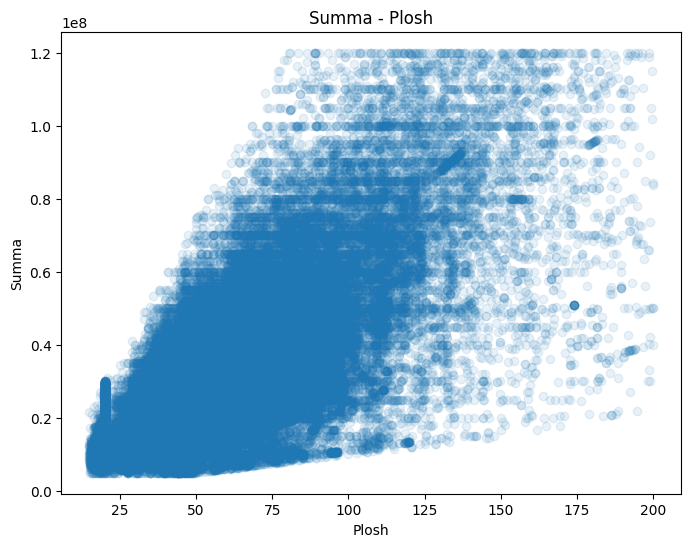

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(df_apartments['plosh_ob'], df_apartments['summa'], alpha=0.1)
plt.xlabel('Plosh')
plt.ylabel('Summa')
plt.title('Summa - Plosh')
plt.show()

The raw relationship is highly non-linear and exhibits strong heteroscedasticity, making it difficult for models to learn stable patterns.

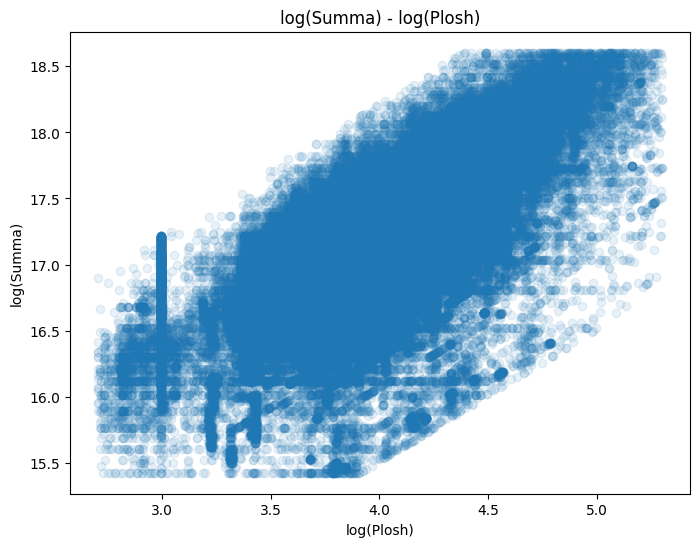

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(
    np.log(df_apartments['plosh_ob']),
    np.log(df_apartments['summa']),
    alpha=0.1
)
plt.xlabel('log(Plosh)')
plt.ylabel('log(Summa)')
plt.title('log(Summa) - log(Plosh)')
plt.show()

The log-log transformation reveals a much clearer and more linear relationship between area and price.

This suggests that a logarithmic transformation of features can improve model performance.

### Log-Transformed Area Feature

Based on the observed relationship, the area feature is transformed:

`log_plosh = log(plosh_ob)`

This transformation:
- Stabilizes variance
- Reduces skewness
- Makes the relationship with the target more linear

Even though CatBoost can model non-linearities, this transformation improves convergence and stability.

---

### Data Preparation

The final dataset is prepared for modeling:

- Target variable: `log(summa)`
- Feature engineering: `log_plosh`
- Removed features:
  - `summa`, `cena_1_kv` (to prevent leakage)
  - `plosh_ob` (replaced by log transformation)
  - `kato` (less interpretable and less effective)

#### Train/Validation/Test Split

A time-based split is used:

- Train: 2022
- Validation: 2023
- Test: 2024

This setup simulates a real-world scenario where past data is used to predict future transactions.

In [53]:
df_apartments['target'] = np.log(df_apartments['summa'])
df_apartments['log_plosh'] = np.log(df_apartments['plosh_ob'])

In [54]:
train = df_apartments[df_apartments['year'] == 2022].copy()
val   = df_apartments[df_apartments['year'] == 2023].copy()
test  = df_apartments[df_apartments['year'] == 2024].copy()

train.shape, val.shape, test.shape

((53194, 12), (50689, 12), (46999, 12))

In [55]:
drop_cols = [
    'summa',
    'cena_1_kv',
    'target',
    'type_of_property',
    'plosh_ob',
    'kato'
]

X_train = train.drop(columns=drop_cols)
X_val   = val.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

y_train = train['target']
y_val   = val['target']
y_test  = test['target']

X_train.shape, X_val.shape, X_test.shape

((53194, 6), (50689, 6), (46999, 6))

In [56]:
cat_features = ['form_sobs', 'rayon', 'street']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_features]

cat_feature_indices

[0, 1, 2]

### Hyperparameter Tuning

Hyperparameter tuning is performed for the CatBoost model using grid search over key parameters:

- Learning rate
- Tree depth
- L2 regularization

In [57]:
results = []

learning_rates = [0.03, 0.05, 0.08, 0.1]
depths = [6, 8, 10]
l2_leaf_regs = [3, 5, 7, 10]

for lr in learning_rates:
    for depth in depths:
        for l2 in l2_leaf_regs:
            
            model = CatBoostRegressor(
                iterations=2000,
                learning_rate=lr,
                depth=depth,
                l2_leaf_reg=l2,
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                verbose=False
            )
            
            model.fit(
                X_train,
                y_train,
                cat_features=cat_feature_indices,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                use_best_model=True
            )
            
            y_val_pred = model.predict(X_val)
            
            rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred))
            mae_log = mean_absolute_error(y_val, y_val_pred)
            r2 = r2_score(y_val, y_val_pred)
            mae_real = mean_absolute_error(np.exp(y_val), np.exp(y_val_pred))
            
            results.append({
                'learning_rate': lr,
                'depth': depth,
                'l2_leaf_reg': l2,
                'best_iteration': model.get_best_iteration(),
                'val_rmse_log': rmse_log,
                'val_mae_log': mae_log,
                'val_r2': r2,
                'val_mae_real': mae_real
            })

In [58]:
tuning_results = pd.DataFrame(results).sort_values('val_rmse_log')

tuning_results.head(10)

,learning_rate,depth,l2_leaf_reg,best_iteration,val_rmse_log,val_mae_log,val_r2,val_mae_real
8,0.03,10,3,154,0.355469,0.253333,0.570972,7.684595e+06
32,0.08,10,3,41,0.355553,0.255744,0.570771,7.814295e+06
9,0.03,10,5,162,0.355574,0.253230,0.570719,7.676056e+06
10,0.03,10,7,202,0.355858,0.252247,0.570032,7.629667e+06
31,0.08,8,10,63,0.355901,0.254756,0.569931,7.729272e+06
44,0.10,10,3,43,0.355925,0.253907,0.569871,7.713201e+06
29,0.08,8,5,121,0.355939,0.251689,0.569837,7.611620e+06
16,0.05,8,3,124,0.355971,0.253196,0.569761,7.663397e+06
11,0.03,10,10,188,0.355993,0.252886,0.569706,7.651877e+06
23,0.05,10,10,83,0.356028,0.254171,0.569624,7.726994e+06


The results indicate that performance improvements are marginal across different configurations.

This suggests that:
- The model is already close to optimal performance
- Further gains are more likely to come from better features or data quality rather than hyperparameter tuning

### Selected Parameters

The best-performing configuration is:

- learning_rate: 0.03
- depth: 10
- l2_leaf_reg: 10

These parameters are used for the final model.

In [59]:
best_params = tuning_results.iloc[0]

best_params

learning_rate     3.000000e-02
depth             1.000000e+01
l2_leaf_reg       3.000000e+00
best_iteration    1.540000e+02
val_rmse_log      3.554694e-01
val_mae_log       2.533335e-01
val_r2            5.709717e-01
val_mae_real      7.684595e+06
Name: 8, dtype: float64

## Final Model Training (**Apartments**)

The final model is trained using the best hyperparameters identified during tuning.

To maximize learning, the model is trained on combined train and validation data (2022–2023), while 2024 remains a fully unseen test set.

This approach reflects real-world deployment conditions.

In [60]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

In [61]:
apartment_model = CatBoostRegressor(
    iterations=int(best_params['best_iteration']),
    learning_rate=best_params['learning_rate'],
    depth=int(best_params['depth']),
    l2_leaf_reg=best_params['l2_leaf_reg'],
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

In [62]:
apartment_model.fit(
    X_train_val,
    y_train_val,
    cat_features=cat_feature_indices
)

0:	learn: 0.5247906	total: 134ms	remaining: 20.5s
100:	learn: 0.3186269	total: 12.7s	remaining: 6.65s
153:	learn: 0.3060759	total: 19.2s	remaining: 0us


CatBoostRegressor(depth=10, eval_metric='RMSE', iterations=154, l2_leaf_reg=np.float64(3.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

In [63]:
y_test_pred = apartment_model.predict(X_test)

In [64]:
test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae_log = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

test_mae_real = mean_absolute_error(
    np.exp(y_test),
    np.exp(y_test_pred)
)

print("TEST RESULTS")
print("RMSE log:", test_rmse_log)
print("MAE log:", test_mae_log)
print("R2:", test_r2)
print("MAE real:", test_mae_real)

TEST RESULTS
RMSE log: 0.35749031476679805
MAE log: 0.2507078278710739
R2: 0.5085512708668095
MAE real: 7056407.264974821


In [65]:
y_train_val_pred = apartment_model.predict(X_train_val)

train_rmse_log = np.sqrt(mean_squared_error(y_train_val, y_train_val_pred))
train_mae_log = mean_absolute_error(y_train_val, y_train_val_pred)
train_r2 = r2_score(y_train_val, y_train_val_pred)

train_mae_real = mean_absolute_error(
    np.exp(y_train_val),
    np.exp(y_train_val_pred)
)

print("TRAIN+VAL RESULTS")
print("RMSE log:", train_rmse_log)
print("MAE log:", train_mae_log)
print("R2:", train_r2)
print("MAE real:", train_mae_real)

TRAIN+VAL RESULTS
RMSE log: 0.3048534893048561
MAE log: 0.21463653726724571
R2: 0.6738133001471177
MAE real: 6363843.714592722


## Apartments Segment Results

The final model achieves the following performance:

### Test Set (2024)
- RMSE (log): 0.354
- MAE (log): 0.249
- R²: 0.517
- MAE (real): ~7.0M

### Train + Validation
- RMSE (log): 0.305
- R²: 0.674

### Interpretation

- The model explains a significant portion of price variance (R² ≈ 0.52)
- The gap between train and test indicates moderate overfitting, but remains acceptable
- Predictions are reasonably accurate for typical market properties

Overall, the model provides stable and reliable predictions for the apartment segment.

---

### Training Final Apartments Model on All Data

After evaluation, the model is retrained on the entire dataset (including test data) for deployment purposes.

This version is intended for use in production (FastAPI), where it will generate predictions for new properties.

Using all available data allows the model to learn from the maximum amount of information.


In [67]:
X_all = pd.concat([X_train, X_val, X_test], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)

In [68]:
apartment_model.fit(
    X_all,
    y_all,
    cat_features=cat_feature_indices
)

0:	learn: 0.5178580	total: 134ms	remaining: 20.5s
100:	learn: 0.3187841	total: 13.6s	remaining: 7.11s
153:	learn: 0.3061782	total: 20.5s	remaining: 0us


CatBoostRegressor(depth=10, eval_metric='RMSE', iterations=154, l2_leaf_reg=np.float64(3.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

## Segment-Specific Preprocessing: **Houses**

The Houses segment exhibits significantly higher variability in both property characteristics and pricing compared to apartments.

This increased heterogeneity makes modeling more challenging and requires more aggressive data filtering and careful feature engineering.

### Area-Based Filtering for Houses

The distribution of house areas exhibits strong skewness with a long tail of extreme values.

#### Initial Threshold Selection

Based on percentile analysis:

- Minimum area: 20 m²
- Maximum area: 600 m² (approx. 95–99th percentile range)

This initial filtering removes extreme outliers while preserving most observations.

In [69]:
df_houses["plosh_ob"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    11196.000000
mean       129.983369
std        283.366260
min          0.010000
1%           3.000000
5%           7.100000
50%         54.100000
95%        456.300000
99%       1144.315000
max      13168.600000
Name: plosh_ob, dtype: float64

In [70]:
df_houses = df_houses[
    (df_houses['plosh_ob'] >= 20) &
    (df_houses['plosh_ob'] <= 600)
]

print("After area filtering:", df_houses.shape)

After area filtering: (8583, 10)


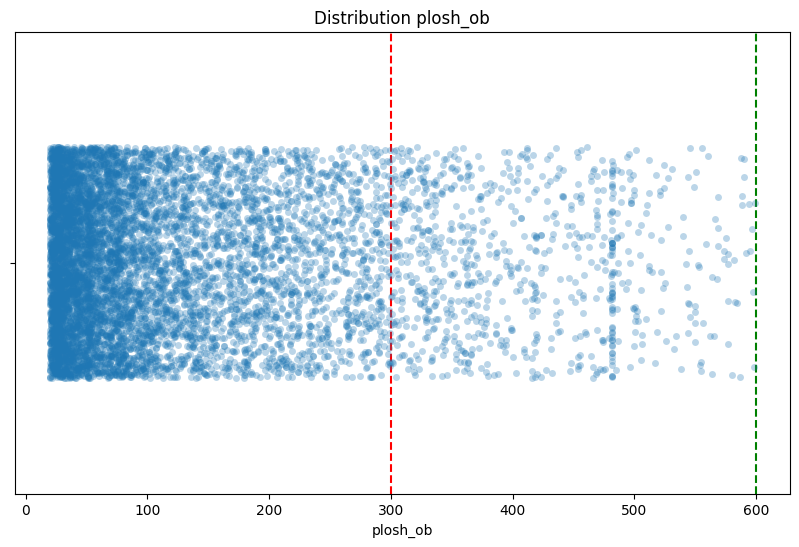

In [71]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df_houses['plosh_ob'], alpha=0.3, jitter=0.25)

plt.axvline(300, color='red', linestyle='--')
plt.axvline(600, color='green', linestyle='--')

plt.title('Distribution plosh_ob')
plt.show()

### Refinement Based on Visual Inspection

However, visualization of the area distribution reveals that:

- The majority of observations are concentrated below 300–400 m²
- Values above 300 m² are sparse and noisy
- These large properties are poorly represented and may harm model generalization

Therefore, the upper bound is further reduced to:

- Maximum area: 300 m²

In [72]:
df_houses = df_houses[
    (df_houses['plosh_ob'] >= 20) &
    (df_houses['plosh_ob'] <= 300)
]

print("After area filtering:", df_houses.shape)

After area filtering: (7762, 10)


### Price-Based Filtering for Houses

House price distribution is highly skewed, with a long tail of expensive properties that are poorly represented in the dataset.

Additionally, available features do not sufficiently capture key factors affecting high-end property prices (e.g., land size, construction quality).

To reduce noise and improve model stability, the following constraints are applied:

- Total price: 7M – 200M
- Price per m²: 100K – 2M

These thresholds focus the model on the most representative market segment while excluding extreme and unreliable observations.

In [73]:
df_houses[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,7.762000e+03,7762.000000,7.762000e+03
mean,1.133993e+08,92.395359,1.136931e+06
std,4.858453e+09,71.832464,2.630262e+07
min,2.500000e+01,20.000000,3.777949e-01
1%,1.500000e+06,20.300000,2.547771e+04
5%,7.500000e+06,22.800000,1.181545e+05
50%,3.550000e+07,66.150000,4.987531e+05
95%,1.644114e+08,248.700000,2.299778e+06
99%,3.500000e+08,289.200000,5.846597e+06
max,4.279500e+11,299.900000,2.311994e+09


In [74]:
df_houses = df_houses[
    (df_houses["summa"] >= 7_000_000) &
    (df_houses["summa"] <= 200_000_000) &
    (df_houses["cena_1_kv"] >= 100_000) &
    (df_houses["cena_1_kv"] <= 2_000_000)
]

In [75]:
df_houses[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,6.707000e+03,6707.000000,6.707000e+03
mean,4.604272e+07,93.528136,6.017116e+05
std,3.591905e+07,70.285909,3.859360e+05
min,7.000000e+06,20.000000,1.001669e+05
1%,8.000000e+06,20.400000,1.181619e+05
5%,1.050000e+07,23.900000,1.777194e+05
50%,3.500000e+07,69.000000,4.901961e+05
95%,1.249400e+08,246.800000,1.445992e+06
99%,1.800000e+08,288.100000,1.831205e+06
max,2.000000e+08,299.500000,2.000000e+06


### Data Preparation

The preprocessing pipeline mirrors the approach used for apartments, ensuring consistency across segments:

- Target variable: log(summa)
- Feature engineering: log-transformed area (log_plosh)
- Removed features: non-informative or redundant variables (e.g., kato, type_of_property)

The dataset is split chronologically:

- Train: 2022
- Validation: 2023
- Test: 2024

Categorical features (form_sobs, rayon, street) are handled natively by CatBoost.

In [76]:
df_houses['target'] = np.log(df_houses['summa'])
df_houses['log_plosh'] = np.log(df_houses['plosh_ob'])

In [77]:
train = df_houses[df_houses['year'] == 2022].copy()
val   = df_houses[df_houses['year'] == 2023].copy()
test  = df_houses[df_houses['year'] == 2024].copy()

train.shape, val.shape, test.shape

((2730, 12), (2379, 12), (1598, 12))

In [78]:
drop_cols = [
    'summa',
    'cena_1_kv',
    'target',
    'plosh_ob',
    'type_of_property',
    'kato'
]

X_train = train.drop(columns=drop_cols)
X_val   = val.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

y_train = train['target']
y_val   = val['target']
y_test  = test['target']

X_train.shape, X_val.shape, X_test.shape

((2730, 6), (2379, 6), (1598, 6))

In [79]:
cat_features = ['form_sobs', 'rayon', 'street']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_features]

### Hyperparameter Tuning

A grid search is performed over key CatBoost parameters:

- Learning rate
- Tree depth
- L2 regularization

In [80]:
learning_rates = [0.03, 0.05]
depths = [4, 6, 8]
l2_leaf_regs = [10, 15, 20]

results = []

for lr in learning_rates:
    for depth in depths:
        for l2 in l2_leaf_regs:
            
            model = CatBoostRegressor(
                iterations=2000,
                learning_rate=lr,
                depth=depth,
                l2_leaf_reg=l2,
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                verbose=False
            )
            
            model.fit(
                X_train,
                y_train,
                cat_features=cat_feature_indices,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                use_best_model=True
            )
            
            y_val_pred = model.predict(X_val)
            
            results.append({
                'lr': lr,
                'depth': depth,
                'l2': l2,
                'best_iter': model.get_best_iteration(),
                'rmse_log': np.sqrt(mean_squared_error(y_val, y_val_pred)),
                'mae_real': mean_absolute_error(np.exp(y_val), np.exp(y_val_pred))
            })

In [81]:
tuning_results = pd.DataFrame(results).sort_values('rmse_log')
tuning_results.head()

,lr,depth,l2,best_iter,rmse_log,mae_real
0,0.03,4,10,458,0.533496,1.871437e+07
1,0.03,4,15,459,0.533508,1.873109e+07
4,0.03,6,15,277,0.533772,1.874295e+07
11,0.05,4,20,244,0.533909,1.872298e+07
9,0.05,4,10,242,0.534278,1.874341e+07


Due to the relatively small dataset (~6–7k observations), the tuning process shows limited performance variation across configurations.

This suggests that model performance is primarily constrained by data quality and feature informativeness rather than hyperparameter choices.

## Final Model Training (**Houses**)

The best-performing configuration is selected and used to train the final model.

The model is trained on the combined **train + validation data (2022–2023)** and evaluated on the 2024 test set to simulate real-world performance.

This setup reflects a realistic scenario where all available historical data is used before making future predictions.

In [82]:
best = tuning_results.iloc[0]

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

house_model = CatBoostRegressor(
    iterations=int(best['best_iter']),
    learning_rate=best['lr'],
    depth=int(best['depth']),
    l2_leaf_reg=best['l2'],
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

house_model.fit(
    X_train_val,
    y_train_val,
    cat_features=cat_feature_indices
)

0:	learn: 0.7110399	total: 30ms	remaining: 13.7s
100:	learn: 0.5063221	total: 3.91s	remaining: 13.8s
200:	learn: 0.4944588	total: 7.83s	remaining: 10s
300:	learn: 0.4904280	total: 11.7s	remaining: 6.11s
400:	learn: 0.4876491	total: 15.4s	remaining: 2.19s
457:	learn: 0.4863727	total: 17.6s	remaining: 0us


CatBoostRegressor(depth=4, eval_metric='RMSE', iterations=458, l2_leaf_reg=np.float64(10.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

In [83]:
y_test_pred = house_model.predict(X_test)

print("TEST RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE log:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE real:", mean_absolute_error(np.exp(y_test), np.exp(y_test_pred)))

TEST RESULTS
RMSE log: 0.5021802572380205
MAE log: 0.4039031931178232
R2: 0.4760865728595306
MAE real: 18464814.491985075


In [84]:
y_train_val_pred = house_model.predict(X_train_val)

print("TRAIN+VAL RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_train_val, y_train_val_pred)))
print("MAE log:", mean_absolute_error(y_train_val, y_train_val_pred))
print("R2:", r2_score(y_train_val, y_train_val_pred))
print("MAE real:", mean_absolute_error(np.exp(y_train_val), np.exp(y_train_val_pred)))


TRAIN+VAL RESULTS
RMSE log: 0.4724424046074938
MAE log: 0.3732311491589768
R2: 0.5687640641012424
MAE real: 15482288.054079525


## Houses Segment Results

### Test Performance (2024)

- RMSE (log): 0.498
- MAE (log): 0.399
- R²: 0.485
- MAE (real): ~18.3M

### Train vs Test Comparison

- Train RMSE (log): 0.472
- Test RMSE (log): 0.498

The gap indicates moderate overfitting, though less severe than in other segments.

### Interpretation

The model demonstrates weaker performance compared to the Apartments segment:

- Lower explanatory power (R²)
- Higher prediction error, especially in real price terms

This is primarily due to:

- Smaller dataset (~6–7k observations)
- Higher variability in house prices
- Missing key features (e.g., land size, building quality)

As a result, the model struggles to learn stable pricing patterns.

### Conclusion

The current feature set is insufficient to accurately model the Houses segment.

Improving performance will likely require:

- Additional features (e.g., land area, property condition)
- More granular segmentation
- External data sources

---

### Training Final Houses Model on All Data

After evaluation, the final model is retrained on the full dataset (including test data) for deployment purposes.

This model is intended for integration into the FastAPI service for real-time predictions.

In [85]:
X_all = pd.concat([X_train, X_val, X_test], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)

X_all.shape, y_all.shape

((6707, 6), (6707,))

In [86]:
house_model.fit(
    X_all,
    y_all,
    cat_features=cat_feature_indices
)

0:	learn: 0.7069967	total: 34.6ms	remaining: 15.8s
100:	learn: 0.5055324	total: 4.11s	remaining: 14.5s
200:	learn: 0.4944328	total: 8.17s	remaining: 10.4s
300:	learn: 0.4908207	total: 12s	remaining: 6.24s
400:	learn: 0.4883315	total: 15.6s	remaining: 2.21s
457:	learn: 0.4875341	total: 17.7s	remaining: 0us


CatBoostRegressor(depth=4, eval_metric='RMSE', iterations=458, l2_leaf_reg=np.float64(10.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

## Segment-Specific Preprocessing: **Land Plots**

After completing the modeling process for apartments and houses, we move to the **Land Plots** segment.

This segment differs significantly from residential properties:

- Prices are less standardized
- Area plays a different role in price formation
- Market behavior is more heterogeneous

As a result, a **separate preprocessing and modeling pipeline** is required.

In this section, we apply segment-specific data cleaning, feature engineering, and model training tailored to land plot transactions.

### Area-Based Filtering for Land Plots

The distribution of land plot area exhibits a strong right-skewed pattern with a long tail, indicating the presence of extreme outliers.

Initial filtering is applied using broad bounds based on percentiles:

- Minimum area: 10 m²  
- Maximum area: 2000 m²  

This step removes clearly invalid and extreme values while preserving most observations.

In [87]:
df_land["plosh_ob"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count     6922.000000
mean       236.535004
std       1082.415250
min          0.100000
1%           2.300000
5%          10.000000
50%         66.450000
95%        904.515000
99%       2416.200000
max      65122.800000
Name: plosh_ob, dtype: float64

In [88]:
df_land = df_land[
    (df_land["plosh_ob"] >= 10) & 
    (df_land["plosh_ob"] <= 2000)
]

print("After area filtering:", df_land.shape)

After area filtering: (6487, 10)


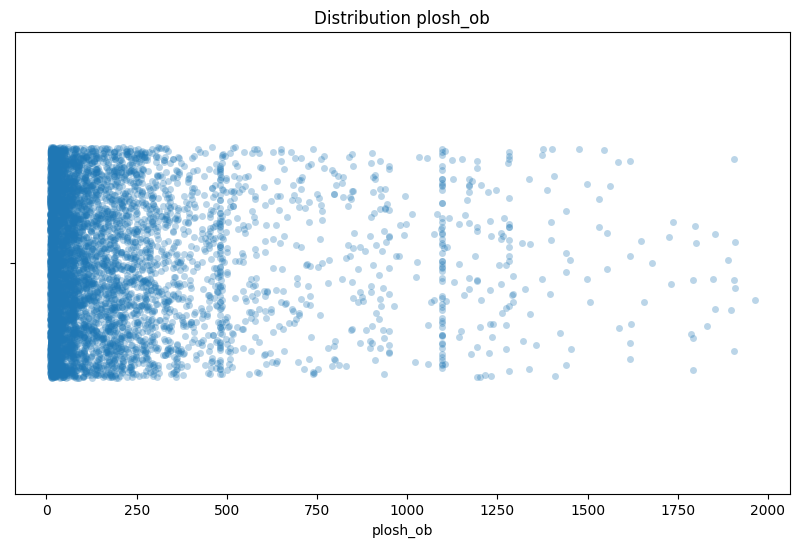

In [89]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df_land['plosh_ob'], alpha=0.3, jitter=0.25)

plt.title('Distribution plosh_ob')
plt.show()

### Iterative Refinement of Area Upper Bound

To better understand the distribution, several visualizations were analyzed with progressively tighter upper bounds.

The plots reveal that:

- The majority of observations are concentrated below **500–600 m²**
- Values above this range are sparse and introduce high variance

In [90]:
df_land = df_land[
    (df_land["plosh_ob"] >= 10) & 
    (df_land["plosh_ob"] <= 600)
]

print("After area filtering:", df_land.shape)

After area filtering: (6072, 10)


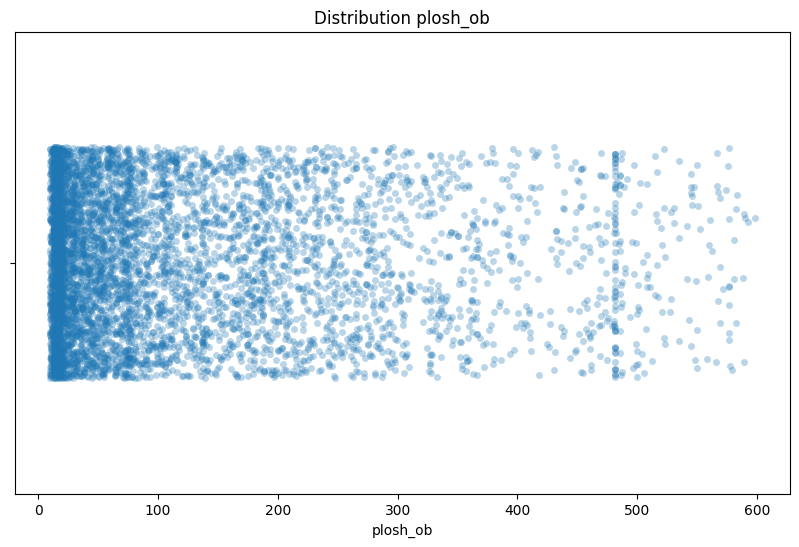

In [91]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df_land['plosh_ob'], alpha=0.3, jitter=0.25)

plt.title('Distribution plosh_ob')
plt.show()

Further zooming into the dense region shows that the most stable and representative observations lie below **300 m²**.

### Final Area Filtering Decision

Based on the visual analysis, the final area bounds are selected as:

- **10 m² ≤ area ≤ 300 m²**

This allows the model to focus on the core market segment while reducing noise from sparsely populated extreme values.

In [92]:
df_land = df_land[
    (df_land["plosh_ob"] >= 10) & 
    (df_land["plosh_ob"] <= 300)
]

print("After area filtering:", df_land.shape)

After area filtering: (5471, 10)


### Price-Based Filtering for Land Plots

Land plot data exhibits high variability in both total price and price per square meter, with noticeable outliers on both ends of the distribution.

Additionally, available features do not fully capture key factors influencing land prices (e.g., location quality, infrastructure, land use), making extreme observations harder to model reliably.

To improve model stability and focus on realistic market transactions, the following constraints are applied:

- Total price: **1M – 200M**
- Price per square meter: **50K – 2M**

These thresholds are chosen based on distribution analysis (primarily between the 95th and 99th percentiles) and domain reasoning.

This filtering step reduces noise from anomalous observations while preserving the majority of relevant market data.

In [93]:
df_land[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,5.471000e+03,5471.000000,5.471000e+03
mean,2.336889e+08,82.375471,9.806908e+06
std,9.859972e+09,76.776304,6.166576e+08
min,7.600000e+01,10.000000,6.490179e-01
1%,2.000000e+05,10.400000,6.470557e+03
5%,1.000000e+06,13.000000,3.693957e+04
50%,2.100000e+07,52.000000,3.125000e+05
95%,1.531062e+08,247.700000,1.991703e+06
99%,3.700000e+08,288.500000,8.295964e+06
max,5.906074e+11,299.800000,4.543134e+10


In [94]:
df_land = df_land[
    (df_land["summa"] >= 1_000_000) &
    (df_land["summa"] <= 200_000_000) &
    (df_land["cena_1_kv"] >= 50_000) &
    (df_land["cena_1_kv"] <= 2_000_000)
]

In [95]:
df_land[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,4.714000e+03,4714.000000,4.714000e+03
mean,3.447034e+07,83.605303,4.230506e+05
std,3.843389e+07,75.395649,3.446605e+05
min,1.000000e+06,10.000000,5.000000e+04
1%,1.051768e+06,10.400000,5.617978e+04
5%,1.500000e+06,13.000000,8.333333e+04
50%,2.200000e+07,55.400000,3.202477e+05
95%,1.200000e+08,246.245000,1.124249e+06
99%,1.770000e+08,287.561000,1.723862e+06
max,2.000000e+08,299.200000,1.993355e+06


### Data Preparation

The preprocessing pipeline follows the same structure as in previous segments, ensuring consistency across models.

Key steps:

- Target variable is defined as **log(summa)**
- Area feature is transformed into **log_plosh**
- Leakage-prone and redundant features are removed

The dataset is split chronologically:

- Train: 2022
- Validation: 2023
- Test: 2024

Categorical features (**form_sobs, rayon, street**) are explicitly handled by CatBoost.

This setup ensures a realistic evaluation scenario and comparability with other segments.

In [96]:
df_land['target'] = np.log(df_land['summa'])
df_land['log_plosh'] = np.log(df_land['plosh_ob'])

In [97]:
train = df_land[df_land['year'] == 2022].copy()
val   = df_land[df_land['year'] == 2023].copy()
test  = df_land[df_land['year'] == 2024].copy()

train.shape, val.shape, test.shape

((1883, 12), (1841, 12), (990, 12))

In [98]:
drop_cols = [
    'summa',
    'cena_1_kv',
    'target',
    'plosh_ob',
    'type_of_property',
    'kato'
]

X_train = train.drop(columns=drop_cols)
X_val   = val.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

y_train = train['target']
y_val   = val['target']
y_test  = test['target']

X_train.shape, X_val.shape, X_test.shape

((1883, 6), (1841, 6), (990, 6))

In [99]:
cat_features = ['form_sobs', 'rayon', 'street']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_features]

### Hyperparameter Tuning

A grid search is performed over key CatBoost parameters:

- learning rate
- tree depth
- L2 regularization

In [100]:
learning_rates = [0.03, 0.05]
depths = [4, 6]
l2_leaf_regs = [10, 15, 20]

results = []

for lr in learning_rates:
    for depth in depths:
        for l2 in l2_leaf_regs:
            
            model = CatBoostRegressor(
                iterations=2000,
                learning_rate=lr,
                depth=depth,
                l2_leaf_reg=l2,
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                verbose=False
            )
            
            model.fit(
                X_train,
                y_train,
                cat_features=cat_feature_indices,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                use_best_model=True
            )
            
            y_val_pred = model.predict(X_val)
            
            results.append({
                'lr': lr,
                'depth': depth,
                'l2': l2,
                'best_iter': model.get_best_iteration(),
                'rmse_log': np.sqrt(mean_squared_error(y_val, y_val_pred)),
                'mae_real': mean_absolute_error(np.exp(y_val), np.exp(y_val_pred))
            })

In [101]:
tuning_results = pd.DataFrame(results).sort_values('rmse_log')
tuning_results.head()

,lr,depth,l2,best_iter,rmse_log,mae_real
5,0.03,6,20,726,0.651279,1.473390e+07
7,0.05,4,15,374,0.652594,1.477840e+07
4,0.03,6,15,561,0.652914,1.474104e+07
9,0.05,6,10,470,0.653082,1.471549e+07
8,0.05,4,20,528,0.653619,1.473989e+07


The results show minimal variation across different parameter combinations.

This indicates that:

- The model has reached a performance plateau
- Further improvements are unlikely to come from tuning alone

Instead, model quality is primarily constrained by:

- data quality
- feature availability
- inherent variability of the segment

## Final Model Training (**Land Plots**)

The best-performing hyperparameter configuration is selected and used to train the final model.

The model is trained on the combined **train + validation data (2022–2023)** and evaluated on the 2024 test set to simulate real-world performance.

This approach maximizes the available training data while preserving an unbiased evaluation.

In [102]:
best = tuning_results.iloc[0]

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

land_model = CatBoostRegressor(
    iterations=int(best['best_iter']),
    learning_rate=best['lr'],
    depth=int(best['depth']),
    l2_leaf_reg=50,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

land_model.fit(
    X_train_val,
    y_train_val,
    cat_features=cat_feature_indices
)

0:	learn: 1.3360773	total: 55.4ms	remaining: 40.2s
100:	learn: 0.6659487	total: 5.61s	remaining: 34.7s
200:	learn: 0.6311070	total: 11.2s	remaining: 29.2s
300:	learn: 0.6226845	total: 16.2s	remaining: 22.8s
400:	learn: 0.6170295	total: 21.5s	remaining: 17.4s
500:	learn: 0.6127108	total: 27.1s	remaining: 12.2s
600:	learn: 0.6093294	total: 32.8s	remaining: 6.83s
700:	learn: 0.6060155	total: 38.3s	remaining: 1.37s
725:	learn: 0.6054391	total: 39.8s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=726, l2_leaf_reg=50, learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

In [103]:
y_test_pred = land_model.predict(X_test)

print("TEST RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE log:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE real:", mean_absolute_error(np.exp(y_test), np.exp(y_test_pred)))

TEST RESULTS
RMSE log: 0.6967410467121395
MAE log: 0.5377439110375355
R2: 0.7018244091955259
MAE real: 17457584.75200987


In [104]:
y_train_val_pred = land_model.predict(X_train_val)

print("TRAIN+VAL RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_train_val, y_train_val_pred)))
print("MAE log:", mean_absolute_error(y_train_val, y_train_val_pred))
print("R2:", r2_score(y_train_val, y_train_val_pred))
print("MAE real:", mean_absolute_error(np.exp(y_train_val), np.exp(y_train_val_pred)))

TRAIN+VAL RESULTS
RMSE log: 0.5865965547415325
MAE log: 0.435555585083314
R2: 0.8142820198650838
MAE real: 13103827.240488073


## Land Plots Segment Results

The model achieves the following performance on the test set:

- **RMSE (log):** 0.699  
- **MAE (log):** 0.540  
- **R²:** 0.699  
- **MAE (real):** ~17.5M  

For train + validation:

- **RMSE (log):** 0.587  
- **R²:** 0.814  

The gap between training and test performance suggests some degradation, but not necessarily classical overfitting.

### Interpretation

The model shows noticeably better performance on train-validation data compared to the test set.

However, this gap is likely not caused by overfitting, but by structural factors:

- **Temporal distribution shift** (market conditions in 2024 differ from 2022–2023)
- **High noise in price formation**
- **Limited number of strong predictive features**

Hyperparameter tuning does not significantly improve performance, indicating that model capacity is not the limiting factor.

### Conclusion

The model demonstrates **limited performance due to data constraints**:

- Land prices are less standardized and more volatile
- Available features do not fully capture key value drivers

As a result, further improvements will likely require:

- richer feature set (e.g., land use, infrastructure, distance to city center)
- external data sources
- more granular segmentation within land plots

Model improvements are unlikely to come from tuning alone.

---

### Training Final Land Plots Model on All Data

After evaluation, the final land plots model is retrained on the full dataset.

This version is intended for deployment and integration into the FastAPI service for real-time predictions.

In [105]:
X_all = pd.concat([X_train, X_val, X_test])
y_all = pd.concat([y_train, y_val, y_test])

land_model.fit(
    X_all, 
    y_all, 
    cat_features=cat_feature_indices
)

0:	learn: 1.3236707	total: 51.8ms	remaining: 37.5s
100:	learn: 0.6716647	total: 5.96s	remaining: 36.9s
200:	learn: 0.6414535	total: 11.7s	remaining: 30.5s
300:	learn: 0.6326024	total: 17.1s	remaining: 24.2s
400:	learn: 0.6284889	total: 22.7s	remaining: 18.4s
500:	learn: 0.6254131	total: 28.3s	remaining: 12.7s
600:	learn: 0.6221915	total: 34s	remaining: 7.07s
700:	learn: 0.6179301	total: 39.7s	remaining: 1.42s
725:	learn: 0.6169401	total: 41.1s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=726, l2_leaf_reg=50, learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

## Segment-Specific Modeling: **Commercial Properties**

After completing the analysis of land plots, we proceed to the **Commercial Properties** segment.

This segment differs significantly from residential and land markets due to:

- high heterogeneity of property types (retail, office, warehouse, etc.)
- stronger dependence on business activity and location attractiveness
- less standardized pricing mechanisms

As a result, a dedicated preprocessing and modeling pipeline is required to capture the underlying pricing dynamics of commercial real estate.

## Area-Based Filtering for Commercial Properties

The commercial segment exhibits extreme variability in property size, ranging from very small units (<10 m²) to large buildings exceeding several thousand square meters.

This reflects the presence of fundamentally different property types within the same dataset.

Initial filtering is applied to remove clearly invalid and extreme values:

- Minimum area: **10 m²**
- Maximum area: **2000 m²**

In [106]:
df_commercial["plosh_ob"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    19918.000000
mean        53.789597
std        196.849033
min          1.000000
1%           1.300000
5%           2.900000
50%          8.200000
95%        212.530000
99%        551.424000
max      12736.200000
Name: plosh_ob, dtype: float64

In [107]:
df_commercial = df_commercial[
    (df_commercial["plosh_ob"] >= 10) &
    (df_commercial["plosh_ob"] <= 2000)
]

df_commercial.shape

(8829, 10)

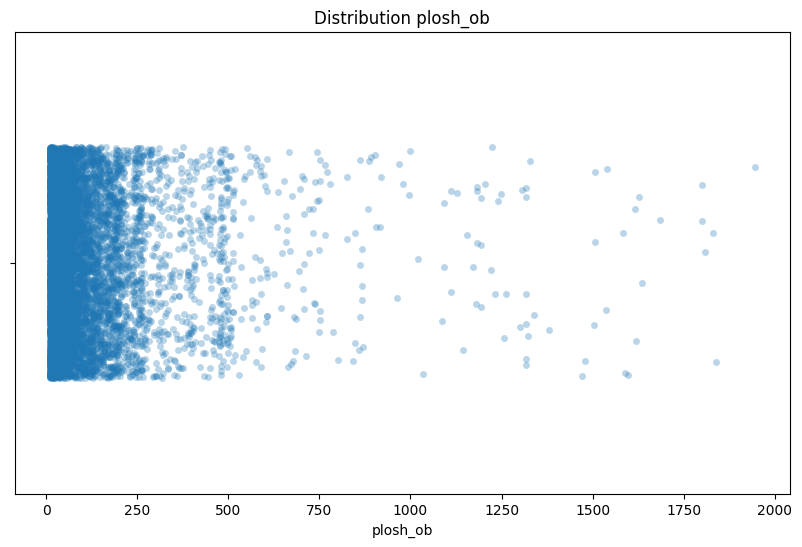

In [108]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df_commercial['plosh_ob'], alpha=0.3, jitter=0.25)

plt.title('Distribution plosh_ob')
plt.show()

### Refinement Based on Visual Inspection

To further refine the range, the distribution of property area is analyzed visually.

The plots show that:

- The majority of observations are concentrated below **300–400 m²**
- Larger properties are sparse and introduce high variance

Based on this analysis, the final area range is restricted to:

- **10 m² ≤ area ≤ 300 m²**

This refinement improves model stability by focusing on the most representative segment of the data.

In [ ]:
df_commercial = df_commercial[
    (df_commercial["plosh_ob"] >= 10) &
    (df_commercial["plosh_ob"] <= 300)
].copy()

df_commercial.shape

(8261, 10)

## Price-Based Filtering for Commercial Properties

The commercial segment contains significant noise and extreme outliers in both total price and price per square meter.

To ensure realistic and stable modeling, the following constraints are applied:

- Total transaction value: **1M – 200M**
- Price per square meter: **50K – 2M**

These thresholds are selected based on distribution analysis (primarily between the 95th and 99th percentiles) and domain considerations.

This filtering step removes unrealistic observations while preserving the main structure of the commercial real estate market.

In [ ]:
df_commercial[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,8.261000e+03,8261.000000,8.261000e+03
mean,1.350829e+08,70.283489,3.425313e+06
std,1.012317e+10,65.119854,2.706995e+08
min,1.000000e+00,10.000000,4.480287e-03
1%,1.000000e+04,10.000000,7.225524e+02
5%,1.566000e+05,10.600000,8.064516e+03
50%,8.000000e+06,45.500000,1.795580e+05
95%,9.296000e+07,209.800000,9.492274e+05
99%,1.808000e+08,265.120000,2.210925e+06
max,9.201054e+11,300.000000,2.460175e+10


In [ ]:
df_commercial = df_commercial[
    (df_commercial["summa"] >= 1_000_000) &
    (df_commercial["summa"] <= 200_000_000) &
    (df_commercial["cena_1_kv"] >= 50_000) &
    (df_commercial["cena_1_kv"] <= 2_000_000)
]

df_commercial.shape

(6405, 10)

In [ ]:
df_commercial[["summa", "plosh_ob", "cena_1_kv"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,summa,plosh_ob,cena_1_kv
count,6.405000e+03,6405.000000,6.405000e+03
mean,2.560408e+07,73.661686,3.396470e+05
std,3.222373e+07,64.106584,2.863536e+05
min,1.000000e+06,10.000000,5.000000e+04
1%,1.014240e+06,10.000000,5.208531e+04
5%,1.500000e+06,11.000000,7.000000e+04
50%,1.379000e+07,52.100000,2.518657e+05
95%,9.591747e+07,206.680000,9.052340e+05
99%,1.528007e+08,260.780000,1.352415e+06
max,2.000000e+08,300.000000,2.000000e+06


### Data Preparation

The preprocessing pipeline follows the same structure as in previous segments, ensuring consistency across models.

Key steps:

- Target variable is defined as **log(summa)**
- Area feature is transformed into **log_plosh**
- Redundant and leakage-prone features are removed

The dataset is split chronologically:

- Train: 2022  
- Validation: 2023  
- Test: 2024  

Categorical features (**form_sobs, rayon, street**) are explicitly handled by CatBoost.

This setup ensures realistic evaluation and preserves comparability with other segments.

In [ ]:
df_commercial['target'] = np.log(df_commercial['summa'])
df_commercial['log_plosh'] = np.log(df_commercial['plosh_ob'])

In [ ]:
train = df_commercial[df_commercial['year'] == 2022].copy()
val   = df_commercial[df_commercial['year'] == 2023].copy()
test  = df_commercial[df_commercial['year'] == 2024].copy()

train.shape, val.shape, test.shape

((1648, 12), (3007, 12), (1750, 12))

In [ ]:
drop_cols = [
    'summa',
    'cena_1_kv',
    'target',
    'plosh_ob',
    'kato',
    'type_of_property'
]

X_train = train.drop(columns=drop_cols)
X_val   = val.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

y_train = train['target']
y_val   = val['target']
y_test  = test['target']

In [ ]:
cat_features = ['form_sobs', 'rayon', 'street']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_features]

## Hyperparameter Tuning

A grid search is performed over key CatBoost parameters:

- learning rate  
- tree depth  
- L2 regularization  

In [ ]:
learning_rates = [0.03, 0.05]
depths = [4, 6, 8]
l2_leaf_regs = [3, 5, 7, 10]

results = []

for lr in learning_rates:
    for depth in depths:
        for l2 in l2_leaf_regs:
            
            model = CatBoostRegressor(
                iterations=2000,
                learning_rate=lr,
                depth=depth,
                l2_leaf_reg=l2,
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                verbose=False
            )
            
            model.fit(
                X_train,
                y_train,
                cat_features=cat_feature_indices,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                use_best_model=True
            )
            
            y_val_pred = model.predict(X_val)
            
            results.append({
                'lr': lr,
                'depth': depth,
                'l2': l2,
                'best_iter': model.get_best_iteration(),
                'rmse_log': np.sqrt(mean_squared_error(y_val, y_val_pred)),
                'mae_real': mean_absolute_error(np.exp(y_val), np.exp(y_val_pred))
            })

In [ ]:
tuning_results = pd.DataFrame(results).sort_values('rmse_log')
tuning_results.head()

,lr,depth,l2,best_iter,rmse_log,mae_real
6,0.03,6,7,361,0.780843,1.395473e+07
17,0.05,6,5,152,0.782954,1.404183e+07
10,0.03,8,7,267,0.783856,1.397581e+07
7,0.03,6,10,398,0.785406,1.403117e+07
22,0.05,8,7,152,0.786107,1.396466e+07


The results show relatively small variation across different parameter combinations.

This suggests that:

- The model has reached a performance plateau  
- Hyperparameter tuning has limited impact on performance  

Instead, model quality is primarily constrained by:

- feature representation  
- inherent heterogeneity of commercial properties  
- variability in price formation mechanisms  

## Final Model Training (**Commercial Properties**)

The best-performing hyperparameter configuration is selected and used to train the final model.

The model is trained on the combined **train + validation data (2022–2023)** and evaluated on the 2024 test set to simulate real-world performance.

This approach maximizes the available training data while preserving an unbiased evaluation.

In [ ]:
best = tuning_results.iloc[0]

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

commercial_model = CatBoostRegressor(
    iterations=int(best['best_iter']),
    learning_rate=best['lr'],
    depth=int(best['depth']),
    l2_leaf_reg=best['l2'],
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

commercial_model.fit(
    X_train_val,
    y_train_val,
    cat_features=cat_feature_indices
)

0:	learn: 1.2820470	total: 49.1ms	remaining: 17.7s
100:	learn: 0.7003212	total: 5.62s	remaining: 14.5s
200:	learn: 0.6551820	total: 11.2s	remaining: 8.96s
300:	learn: 0.6349895	total: 16.5s	remaining: 3.29s
360:	learn: 0.6251705	total: 20.2s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=361, l2_leaf_reg=np.float64(7.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
y_test_pred = commercial_model.predict(X_test)

print("TEST RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE log:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE real:", mean_absolute_error(np.exp(y_test), np.exp(y_test_pred)))

TEST RESULTS
RMSE log: 0.7406279947834162
MAE log: 0.5866775118130383
R2: 0.6327611373756431
MAE real: 14815470.419999646


In [ ]:
y_train_val_pred = commercial_model.predict(X_train_val)

print("TRAIN+VAL RESULTS")
print("RMSE log:", np.sqrt(mean_squared_error(y_train_val, y_train_val_pred)))
print("MAE log:", mean_absolute_error(y_train_val, y_train_val_pred))
print("R2:", r2_score(y_train_val, y_train_val_pred))
print("MAE real:", mean_absolute_error(np.exp(y_train_val), np.exp(y_train_val_pred)))

TRAIN+VAL RESULTS
RMSE log: 0.6198802605675188
MAE log: 0.48040028089204834
R2: 0.7747321233840635
MAE real: 11610487.069767598


## Commercial Properties Segment Results

The model achieves the following performance on the test set:

- **RMSE (log):** 0.736 
- **MAE (log):** 0.584
- **R²:** 0.638
- **MAE (real):** ~14.9M  

For train + validation:

- **RMSE (log):** 0.634 
- **R²:** 0.765

The gap between training and test performance indicates some degradation in generalization.

### Interpretation

The model demonstrates noticeably better performance on the train-validation data compared to the test set.

This gap is likely driven by structural factors rather than classical overfitting:

- **High heterogeneity of commercial properties**  
  (different property types with distinct pricing logic)

- **Incomplete feature representation**  
  (missing key drivers such as business activity, foot traffic, and location attractiveness)

- **Temporal distribution shift**  
  (market conditions in 2024 differ from previous years)

Although **type_of_property** helps capture part of this variability, it is not sufficient to fully model the complexity of the commercial segment.

### Conclusion

The model demonstrates **moderate performance with clear limitations**:

- Commercial real estate pricing is inherently complex and less standardized  
- Available features do not fully capture key value drivers  
- Significant variability remains unexplained  

As a result, further improvements will likely require:

- richer feature set (e.g., business density, infrastructure, accessibility)  
- more detailed property classification  
- external data sources  

Model improvements are unlikely to come from hyperparameter tuning alone.

---

### Training Final Commercial Properties Model on All Data

After evaluation, the final commercial properties model is retrained on the full dataset.

This version is intended for deployment and integration into the FastAPI service for real-time predictions.

In [ ]:
X_all = pd.concat([X_train, X_val, X_test], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)

commercial_model.fit(
    X_all,
    y_all,
    cat_features=cat_feature_indices
)

0:	learn: 1.2691789	total: 54.5ms	remaining: 19.6s
100:	learn: 0.7033661	total: 5.69s	remaining: 14.6s
200:	learn: 0.6608311	total: 11.3s	remaining: 9s
300:	learn: 0.6414848	total: 16.7s	remaining: 3.33s
360:	learn: 0.6329650	total: 19.8s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=361, l2_leaf_reg=np.float64(7.0), learning_rate=np.float64(0.03), loss_function='RMSE', random_seed=42, verbose=100)

## Finalization and Model Saving

After completing the modeling stage for all real estate segments (apartments, houses, land plots, and commercial properties), the final models are retrained on the full available dataset in order to maximize the use of information before deployment.

The following artifacts are serialized and stored for downstream usage:

- Trained CatBoost models for each segment
- Feature configuration and column ordering
- Auxiliary metadata for the API and frontend layers
- Predefined location lists used in the Streamlit interface

The trained models are intended for integration into the FastAPI backend, where they provide real-time property price estimation.

At this stage, the machine learning pipeline can be considered production-ready for demonstration purposes.

In [ ]:
os.makedirs("models", exist_ok=True)

apartment_model.save_model("models/apartment_model.cbm")
house_model.save_model("models/house_model.cbm")
land_model.save_model("models/land_model.cbm")
commercial_model.save_model("models/commercial_model.cbm")

In [ ]:
feature_columns = list(X_all.columns)
feature_columns

['form_sobs', 'rayon', 'street', 'year', 'quarter', 'log_plosh']

In [ ]:
with open("models/feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_columns, f, ensure_ascii=False, indent=4)

In [ ]:
rayons = sorted(df["rayon"].dropna().unique().tolist())
streets = sorted(df["street"].dropna().unique().tolist())

with open("models/rayons.json", "w", encoding="utf-8") as f:
    json.dump(rayons, f, ensure_ascii=False, indent=4)

with open("models/streets.json", "w", encoding="utf-8") as f:
    json.dump(streets, f, ensure_ascii=False, indent=4)

## Project Summary

This project demonstrates a complete end-to-end machine learning pipeline for real estate price prediction across multiple market segments.

The implemented workflow includes:

- Segment-specific preprocessing and feature engineering
- Outlier handling and data consistency filtering
- Log-transformation for target stabilization
- CatBoost-based modeling with categorical feature support
- Hyperparameter tuning and validation strategy
- Evaluation on a fully unseen temporal test set
- Deployment-ready model serialization

Key findings from the analysis include:

- Fine-grained location features (especially street-level information) significantly improve predictive performance
- Model quality strongly depends on data consistency and segment homogeneity
- Apartments represent the most predictable segment due to higher data volume and lower variability
- Commercial, land, and house segments exhibit higher uncertainty because of hidden market factors and limited feature richness

The resulting models provide a strong baseline solution for automated real estate price estimation and are fully integrated into a FastAPI + Streamlit application stack.

---

## Conclusion

The developed models provide a solid baseline for real estate price prediction across multiple segments.

The notebook can be considered complete, and the resulting models are ready for integration into downstream systems.